In [1]:
#Install the IBM quantum SDK
!pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.6 MB/s eta 0:00:00


In [2]:
#Install the IQM backend QPU API library for Qiskit
!pip install -U "iqm-client[qiskit]==34.0.4"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.8/149.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.4/426.4 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.6/463.6 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.1/80.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 k

In [1]:
#Input your API key from the IQM dashboard and select the QPU such as the 'Garnet' SQUID device

with open('iqm_key.txt', 'r') as file:
  api_key = file.read().strip()

from iqm.qiskit_iqm import IQMProvider
provider = IQMProvider("https://resonance.iqm.tech/", quantum_computer="garnet",
            token=api_key)
backend = provider.get_backend()

You are generating a quantum state from pairs of qubits in superpostion which got entangled! Think of a coin that got flipped into the air and you get a 50% probability that you see heads (e.g. 1) or tails (0) pass by a camera on your phone. If two spinning tops are separated by distance and coupled by a loose rubber band, that is one way to think of entanglement. For a quick primer on the Bell state quantum circuit to enable this check out this Bell state link for this terse explanation from the original physics stack overflow source.

In [2]:
#Run the Bell state circuit composed of 2 quantum circuits
import os
from qiskit import QuantumCircuit, transpile
from iqm.qiskit_iqm import IQMProvider

#Starting with say 8 qubits you run through 4 pairs  (e.g. (0,1), (2,3)) for the hadamard gate and CNOT gate operations
def bell_rng(num_qubits, backend):
    qc = QuantumCircuit(num_qubits, num_qubits)
    for i in range(0, num_qubits, 2):
        control = i
        target = i + 1

        # The control quibit gets the superpostion state and the target quibit gets entangled with it
        # Start with the control qubit going into superposition
        qc.h(control)
        qc.cx(control, target)

    #Run it with the QPU to measure all 8 qubits
    qc.measure(range(num_qubits), range(num_qubits))
    qc_transpiled = transpile(qc, backend=backend)
    # Set use_timeslot=True if you have booked a timeslot
    job = backend.run(qc_transpiled, shots=64, use_timeslot=False)
    result = job.result()
    return result

qubit_range =8
counts = bell_rng(qubit_range, backend).get_counts()
random_8bit_string = list(counts.keys())[0]
print(random_8bit_string)

11001100


A Bell state is prepared with a Hadamard gate applied on the first qubit and a CNOT gate used to add control on the first qubit and a target on the second qubit.

As the quantum computation is reversible, putting a transpose conjugate of the above mentioned gate in reverse order returns the original input.

So, assume that you have some unknown Bell state at the input. Then simply initially run the CNOT gate on the first and second qubit. then run the Hadamard gate on the first qubit (note that the transpose conugate to Hadamard and CNOT gates are the same gates) and measure both qubits in a computational basis. Based on the result of the measurement, you can decide which Bell state was on input:

    measured: |00⟩, Bell state was: 12√(|00⟩+|11⟩)
    measured: |01⟩, Bell state was: 12√(|01⟩+|10⟩)
    measured: |10⟩, Bell state was: 12√(|00⟩−|11⟩)
    measured: |11⟩, Bell state was: 12√(|01⟩−|10⟩)

See this circuit: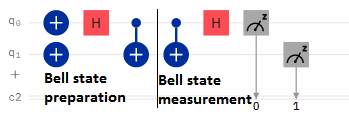

quantum gates at sender/receiver sides

The first part prepares the Bell state (12√(|01⟩−|10⟩)) in particular). Assume that this state was given to us as the receiver. The second part of the circuit is used to recognize which state was given to us. In this case, |11⟩ will be returned with 100 % probability, hence you know that you were given 12√(|01⟩−|10⟩).

In [3]:
#Convert the Bell state circuit outputs from IQM to bytes for the key generation step
def bytes_out(counts):
	bitstring = list(counts.keys())[0]

	bitstring_clean = bitstring.replace(" ", "")
	decimal_value = int(bitstring_clean, 2)
	byte_length = (len(bitstring_clean) + 7) // 8
	out_bytes = decimal_value.to_bytes(byte_length, byteorder="big")
	return out_bytes

raw_quantum_seed = bytes_out(counts) * 32

In [4]:
#Use a modified process for running a cryptograhphic libary to encrypt a message
#Install a classical python based library for encryption such as this one
!pip install pycryptodome

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 40.3 MB/s eta 0:00:00


In [5]:
# Import the Cryptographic library dependencies
from Crypto import Random

from Crypto.Cipher import AES
from Crypto.Hash import HMAC, SHA256

#Encode your secret message  to transmit with the encrypted ciphertext
data = 'not using purely Hadamard gates in the quantum seed for the key'.encode()

cipher = AES.new(raw_quantum_seed, AES.MODE_OCB)
ciphertext, tag = cipher.encrypt_and_digest(data)

# You can now send it through a classical channel to the receiver
with open("encrypted.bin", "wb") as f:
    #f.write(tag)
    #f.write(cipher.nonce)
    f.write(ciphertext)

In [6]:
#Use a Hash based message authentication code with the message and a hashing algorithm to prevent tampering
import hashlib
import hmac

# Redefine generate_hmac_sha256 to accept bytes, as HMAC typically operates on bytes.
# This definition overrides the one from cell 3HKqyjaYlRSb for this cell's execution.
def generate_hmac_sha256(secret_key: bytes, message: bytes,key_file) -> str:
    """Generates an HMAC-SHA256 hex digest for a given message and key.
    This uses bytes as input for secret_key and message.
    """
    with open(key_file, 'rb') as file:
      secret_key_bytes = file.read()
    # HMAC functions expect byte strings directly, so no encoding is needed here.
    hmac_obj = hmac.new(secret_key, msg=message, digestmod=hashlib.sha256)

    # Return the hexadecimal representation of the signature
    return hmac_obj.hexdigest(),secret_key_bytes

The key can be generated through a different random number generator but you should use a Secrets Manager (like AWS Secrets Manager, HashiCorp Vault, Azure Key Vault) to store and retrieve the key securely.
To be crytpgraphically agile you rotate the keys periodically to minimize risk

In [9]:
file ="encrypted.bin"
# The key is the  raw_quantum_seed, which was generated earlier from the Bell state.
key = raw_quantum_seed
# The file is the encrypted binary version
# The 'data' is the encrypted message
signature = generate_hmac_sha256(key, data,file)
print(f"Signature: {signature}")

Signature: ('f456e7e1120b4fcc17a639abc6418ab74260add740c36f96aac3b52bd1919d3e', b'\xd8@\x80\xce`\x11\x1bi}7*RV4\xbfBk^?\xd1\xc2T\xbb\x85\x0e\xaan\x91g;>\x7f\xc1\xcb\xcc1\x07:\x0c\x9d\xbb{Zv\x03\xff;\x9d\x1c\x9bw\x12\xbb\x8d\x07$\xeaob\xf0\xc8=\xc6')
